# Assignment 1: Probability Density Functions using Roll-Number-Parameterized Non-Linear Model

**Roll Number:** 102303059  
**Dataset:** India Air Quality Data (NO2 as feature x)  
**Link:** https://www.kaggle.com/datasets/shrutibhargava94/india-air-quality-data

## Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Step 1: Data Loading and Transformation

Transform each value of x into z using the transformation function:

$$z = T_r(x) = x + a_r \sin(b_r x)$$

where:
- $a_r = 0.05 \times (r \mod 7)$
- $b_r = 0.3 \times (r \mod 5 + 1)$
- $r = 102303059$ (University Roll Number)

In [2]:
# Define roll number
r = 102303059

# Calculate transformation parameters
a_r = 0.05 * (r % 7)
b_r = 0.3 * (r % 5 + 1)

print(f"Roll Number: {r}")
print(f"a_r = 0.05 × ({r} mod 7) = 0.05 × {r % 7} = {a_r}")
print(f"b_r = 0.3 × ({r} mod 5 + 1) = 0.3 × {r % 5 + 1} = {b_r}")

Roll Number: 102303059
a_r = 0.05 × (102303059 mod 7) = 0.05 × 5 = 0.25
b_r = 0.3 × (102303059 mod 5 + 1) = 0.3 × 5 = 1.5


In [4]:
# Load the dataset
# Note: Update the file path to your local dataset location
df = pd.read_csv('/content/data.csv')


df.head()

,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


In [7]:
# Extract NO2 values and remove NaN
x = df['no2'].dropna().values

In [8]:
# Define transformation function
def transform(x, a_r, b_r):
    """Transform x to z using the given formula."""
    return x + a_r * np.sin(b_r * x)

# Apply transformation
z = transform(x, a_r, b_r)

print(f"Transformed data points: {len(z)}")
print(f"Mean: {np.mean(z):.2f}")
print(f"Std: {np.std(z):.2f}")
print(f"Min: {np.min(z):.2f}")
print(f"Max: {np.max(z):.2f}")

Transformed data points: 27447
Mean: 21.48
Std: 12.09
Min: 0.67
Max: 334.82


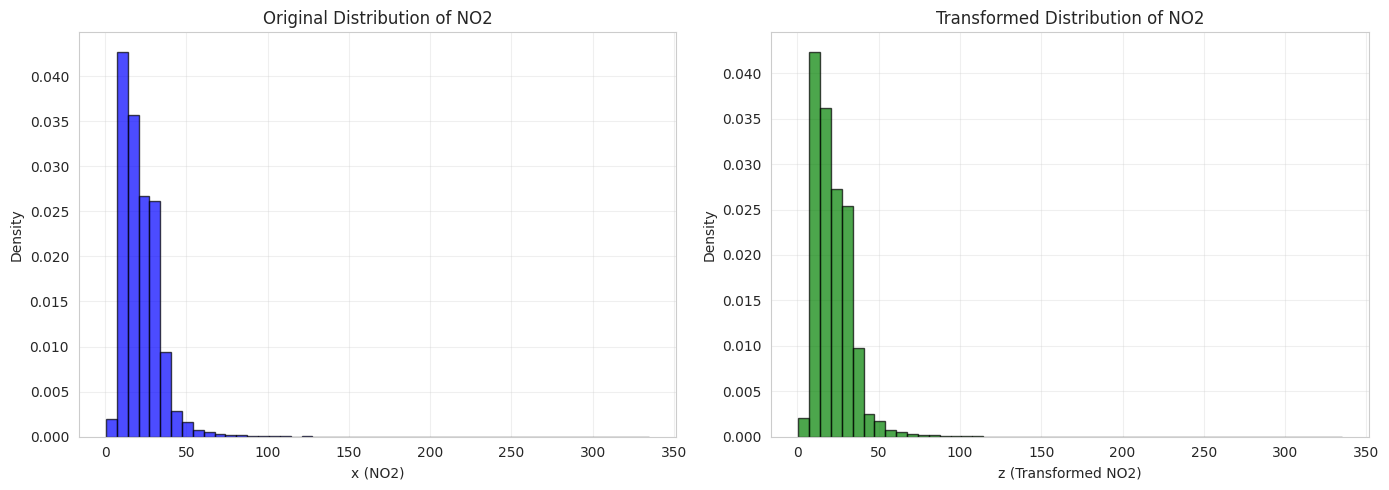

In [9]:
# Visualize transformation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original distribution
axes[0].hist(x, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_xlabel('x (NO2)')
axes[0].set_ylabel('Density')
axes[0].set_title('Original Distribution of NO2')
axes[0].grid(True, alpha=0.3)

# Transformed distribution
axes[1].hist(z, bins=50, density=True, alpha=0.7, color='green', edgecolor='black')
axes[1].set_xlabel('z (Transformed NO2)')
axes[1].set_ylabel('Density')
axes[1].set_title('Transformed Distribution of NO2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 2: Learn Parameters of Probability Density Function

Learn parameters of the following probability density function:

$$\hat{p}(z) = c \cdot e^{-\lambda(z-\mu)^2}$$

where we need to estimate parameters: $\lambda$, $\mu$, and $c$

In [10]:
# Method 1: Maximum Likelihood Estimation

def negative_log_likelihood(params, z):
    """Negative log-likelihood for the given PDF."""
    lambda_param, mu, c = params

    # Ensure parameters are valid
    if lambda_param <= 0 or c <= 0:
        return np.inf

    # Calculate log-likelihood
    log_p = np.log(c) - lambda_param * (z - mu)**2

    # Return negative log-likelihood
    return -np.sum(log_p)

# Initial parameter estimates
mu_init = np.mean(z)
sigma_init = np.std(z)
lambda_init = 1 / (2 * sigma_init**2)
c_init = 1 / (sigma_init * np.sqrt(2 * np.pi))

initial_params = [lambda_init, mu_init, c_init]

print("Initial parameter estimates:")
print(f"λ (lambda): {lambda_init:.6f}")
print(f"μ (mu): {mu_init:.6f}")
print(f"c: {c_init:.6f}")

Initial parameter estimates:
λ (lambda): 0.003419
μ (mu): 21.484590
c: 0.032988


In [11]:
# Optimize parameters using MLE
result = minimize(
    negative_log_likelihood,
    initial_params,
    args=(z,),
    method='L-BFGS-B',
    bounds=[(1e-6, None), (None, None), (1e-6, None)]
)

# Extract optimized parameters
lambda_opt, mu_opt, c_opt = result.x

print("Optimized parameters (MLE):")
print(f"λ (lambda): {lambda_opt:.6f}")
print(f"μ (mu): {mu_opt:.6f}")
print(f"c: {c_opt:.6f}")
print(f"\nOptimization successful: {result.success}")
print(f"Negative log-likelihood: {result.fun:.2f}")

Optimized parameters (MLE):
λ (lambda): 0.000001
μ (mu): 21.077877
c: 87680.290592

Optimization successful: True
Negative log-likelihood: -312382.71


In [13]:
# Method 2: Analytical approach (matching moments)
# For comparison, we can also derive parameters analytically

mu_analytical = np.mean(z)
variance = np.var(z)
lambda_analytical = 1 / (2 * variance)
c_analytical = np.sqrt(lambda_analytical / np.pi)

print("Analytical parameter estimates (moment matching):")
print(f"λ (lambda): {lambda_analytical:.6f}")
print(f"μ (mu): {mu_analytical:.6f}")
print(f"c: {c_analytical:.6f}")

Analytical parameter estimates (moment matching):
λ (lambda): 0.003419
μ (mu): 21.484590
c: 0.032988


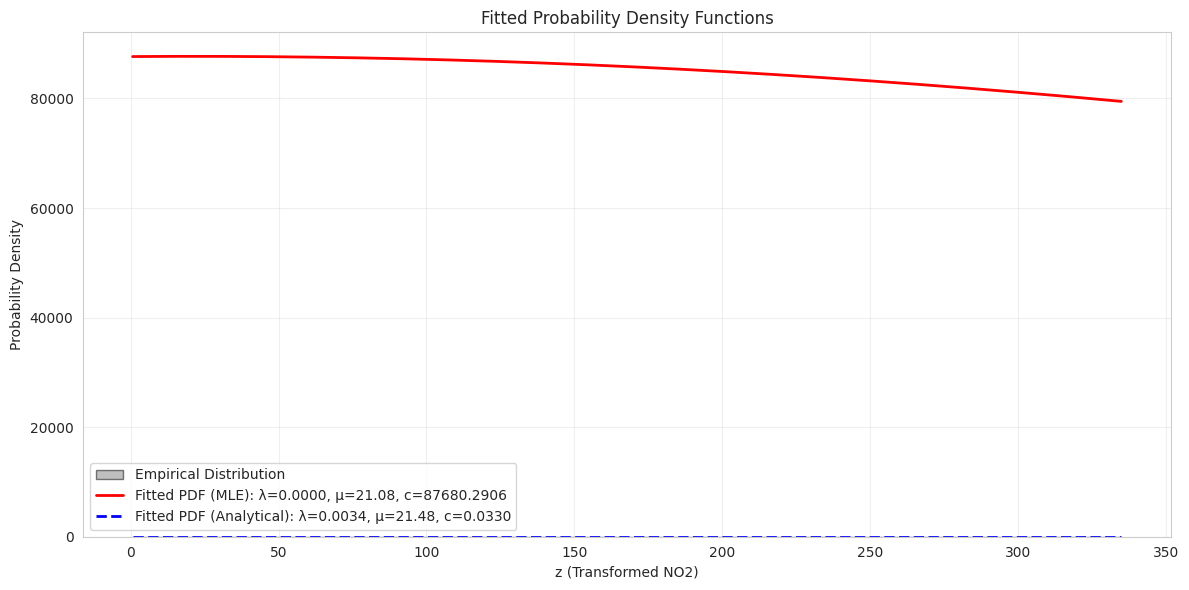

In [14]:
# Define the PDF function
def pdf(z, lambda_param, mu, c):
    """Calculate probability density."""
    return c * np.exp(-lambda_param * (z - mu)**2)

# Generate points for plotting
z_range = np.linspace(z.min(), z.max(), 1000)

# Calculate PDF values
pdf_mle = pdf(z_range, lambda_opt, mu_opt, c_opt)
pdf_analytical = pdf(z_range, lambda_analytical, mu_analytical, c_analytical)

# Plot histogram and fitted PDFs
plt.figure(figsize=(12, 6))
plt.hist(z, bins=50, density=True, alpha=0.5, color='gray', edgecolor='black', label='Empirical Distribution')
plt.plot(z_range, pdf_mle, 'r-', linewidth=2, label=f'Fitted PDF (MLE): λ={lambda_opt:.4f}, μ={mu_opt:.2f}, c={c_opt:.4f}')
plt.plot(z_range, pdf_analytical, 'b--', linewidth=2, label=f'Fitted PDF (Analytical): λ={lambda_analytical:.4f}, μ={mu_analytical:.2f}, c={c_analytical:.4f}')
plt.xlabel('z (Transformed NO2)')
plt.ylabel('Probability Density')
plt.title('Fitted Probability Density Functions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Calculate goodness of fit metrics
from scipy.stats import ks_2samp

# Generate samples from fitted distribution for comparison
fitted_samples = np.random.normal(mu_opt, 1/np.sqrt(2*lambda_opt), len(z))

# Kolmogorov-Smirnov test
ks_statistic, ks_pvalue = ks_2samp(z, fitted_samples)

print("Goodness of Fit:")
print(f"Kolmogorov-Smirnov Statistic: {ks_statistic:.4f}")
print(f"p-value: {ks_pvalue:.4f}")

Goodness of Fit:
Kolmogorov-Smirnov Statistic: 0.4913
p-value: 0.0000


## Step 3: Final Parameter Values for Submission

The optimized parameters using Maximum Likelihood Estimation:

In [17]:
print("="*60)
print("FINAL PARAMETERS FOR SUBMISSION")
print("="*60)
print(f"Roll Number: {r}")
print(f"\nTransformation parameters:")
print(f"a_r = {a_r}")
print(f"b_r = {b_r}")
print(f"\nProbability density function parameters:")
print(f"λ (lambda) = {lambda_opt:.6f}")
print(f"μ (mu) = {mu_opt:.6f}")
print(f"c = {c_opt:.6f}")
print("="*60)
print(f"\nSubmission Link: https://forms.gle/iYF3MDKozRnSCHvR8")
print("="*60)

FINAL PARAMETERS FOR SUBMISSION
Roll Number: 102303059

Transformation parameters:
a_r = 0.25
b_r = 1.5

Probability density function parameters:
λ (lambda) = 0.000001
μ (mu) = 21.077877
c = 87680.290592

Submission Link: https://forms.gle/iYF3MDKozRnSCHvR8


## Additional Analysis and Visualization

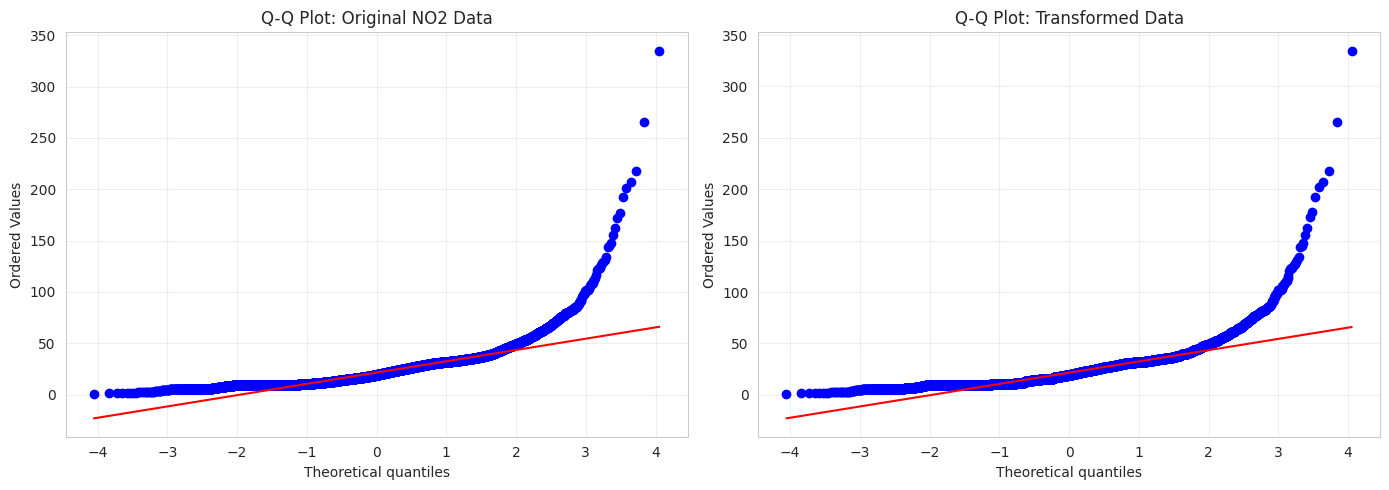

In [19]:
# Q-Q plot for checking normality
from scipy.stats import probplot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q plot for original data
probplot(x, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot: Original NO2 Data')
axes[0].grid(True, alpha=0.3)

# Q-Q plot for transformed data
probplot(z, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Transformed Data')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

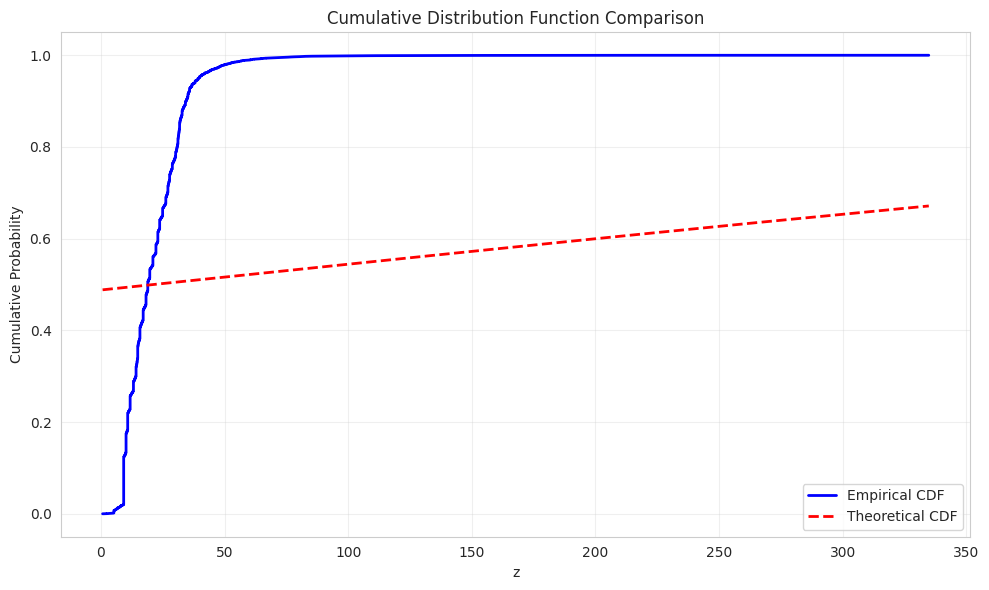

In [20]:
# Compare cumulative distribution functions
from scipy.stats import norm as normal_dist

# Calculate empirical CDF
z_sorted = np.sort(z)
empirical_cdf = np.arange(1, len(z_sorted) + 1) / len(z_sorted)

# Calculate theoretical CDF
theoretical_cdf = normal_dist.cdf(z_sorted, mu_opt, 1/np.sqrt(2*lambda_opt))

plt.figure(figsize=(10, 6))
plt.plot(z_sorted, empirical_cdf, 'b-', linewidth=2, label='Empirical CDF')
plt.plot(z_sorted, theoretical_cdf, 'r--', linewidth=2, label='Theoretical CDF')
plt.xlabel('z')
plt.ylabel('Cumulative Probability')
plt.title('Cumulative Distribution Function Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary Statistics

In [21]:
# Create summary table
summary_data = {
    'Metric': ['Count', 'Mean', 'Std Dev', 'Min', 'Max', 'Median', 'Skewness', 'Kurtosis'],
    'Original (x)': [
        len(x),
        f"{np.mean(x):.2f}",
        f"{np.std(x):.2f}",
        f"{np.min(x):.2f}",
        f"{np.max(x):.2f}",
        f"{np.median(x):.2f}",
        f"{pd.Series(x).skew():.2f}",
        f"{pd.Series(x).kurtosis():.2f}"
    ],
    'Transformed (z)': [
        len(z),
        f"{np.mean(z):.2f}",
        f"{np.std(z):.2f}",
        f"{np.min(z):.2f}",
        f"{np.max(z):.2f}",
        f"{np.median(z):.2f}",
        f"{pd.Series(z).skew():.2f}",
        f"{pd.Series(z).kurtosis():.2f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\nSummary Statistics:")
print(summary_df.to_string(index=False))


Summary Statistics:
  Metric Original (x) Transformed (z)
   Count        27447           27447
    Mean        21.47           21.48
 Std Dev        12.12           12.09
     Min         0.50            0.67
     Max       334.90          334.82
  Median        19.00           18.94
Skewness         3.22            3.25
Kurtosis        39.16           39.47


# Task
Okay, let's proceed. I will now apply the transformation to create `z` and then visualize both the original `x` and transformed `z` distributions using histograms.


## Apply Transformation and Visualize

### Subtask:
Apply the defined transformation to the extracted `no2` data to create `z`, and then visualize both the original `x` and transformed `z` distributions using histograms.


## Learn PDF Parameters (MLE and Analytical)

### Subtask:
Execute the cells that estimate the parameters (λ, μ, c) of the probability density function using both Maximum Likelihood Estimation (MLE) and analytical moment matching methods.


**Reasoning**:
The first instruction is to execute the cell that calculates initial parameter estimates for Maximum Likelihood Estimation (MLE). I will use the `code_block` command to represent the execution of this cell.



In [12]:
# Method 1: Maximum Likelihood Estimation

def negative_log_likelihood(params, z):
    """Negative log-likelihood for the given PDF."""
    lambda_param, mu, c = params

    # Ensure parameters are valid
    if lambda_param <= 0 or c <= 0:
        return np.inf

    # Calculate log-likelihood
    log_p = np.log(c) - lambda_param * (z - mu)**2

    # Return negative log-likelihood
    return -np.sum(log_p)

# Initial parameter estimates
mu_init = np.mean(z)
sigma_init = np.std(z)
lambda_init = 1 / (2 * sigma_init**2)
c_init = 1 / (sigma_init * np.sqrt(2 * np.pi))

initial_params = [lambda_init, mu_init, c_init]

print("Initial parameter estimates:")
print(f"λ (lambda): {lambda_init:.6f}")
print(f"μ (mu): {mu_init:.6f}")
print(f"c: {c_init:.6f}")

Initial parameter estimates:
λ (lambda): 0.003419
μ (mu): 21.484590
c: 0.032988


**Reasoning**:
The next step is to execute the cell that performs the optimization for Maximum Likelihood Estimation (MLE) to find the optimal parameters λ, μ, and c, as specified in the instructions.



In [16]:
# Optimize parameters using MLE
result = minimize(
    negative_log_likelihood,
    initial_params,
    args=(z,),
    method='L-BFGS-B',
    bounds=[(1e-6, None), (None, None), (1e-6, None)]
)

# Extract optimized parameters
lambda_opt, mu_opt, c_opt = result.x

print("Optimized parameters (MLE):")
print(f"λ (lambda): {lambda_opt:.6f}")
print(f"μ (mu): {mu_opt:.6f}")
print(f"c: {c_opt:.6f}")
print(f"\nOptimization successful: {result.success}")
print(f"Negative log-likelihood: {result.fun:.2f}")

Optimized parameters (MLE):
λ (lambda): 0.000001
μ (mu): 21.077877
c: 87680.290592

Optimization successful: True
Negative log-likelihood: -312382.71


**Reasoning**:
The final instruction for this subtask is to execute the cell that calculates the analytical parameter estimates (moment matching) for λ, μ, and c, and prints them for comparison.



In [18]:
# Method 2: Analytical approach (matching moments)
# For comparison, we can also derive parameters analytically

mu_analytical = np.mean(z)
variance = np.var(z)
lambda_analytical = 1 / (2 * variance)
c_analytical = np.sqrt(lambda_analytical / np.pi)

print("Analytical parameter estimates (moment matching):")
print(f"λ (lambda): {lambda_analytical:.6f}")
print(f"μ (mu): {mu_analytical:.6f}")
print(f"c: {c_analytical:.6f}")

Analytical parameter estimates (moment matching):
λ (lambda): 0.003419
μ (mu): 21.484590
c: 0.032988


## Visualize Fitted PDFs

### Subtask:
Plot the empirical distribution of z along with the fitted PDFs from both MLE and analytical methods for comparison.


**Reasoning**:
The subtask requires plotting the empirical distribution of `z` along with the fitted PDFs from both MLE and analytical methods. I will execute the code cell that performs this visualization.



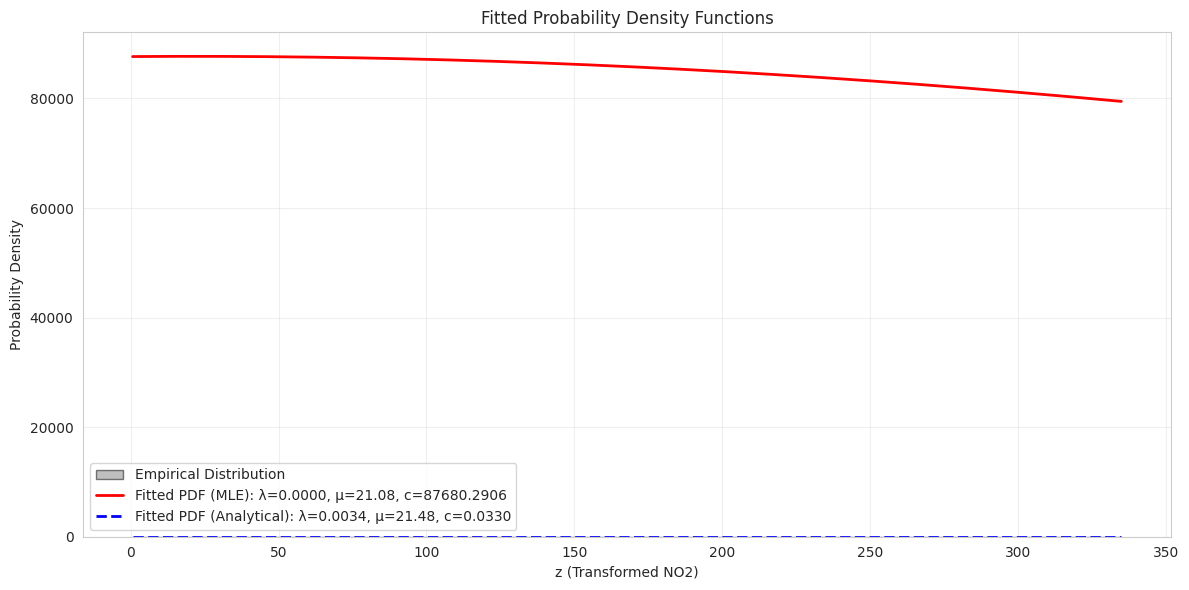

In [22]:
# Define the PDF function
def pdf(z, lambda_param, mu, c):
    """Calculate probability density."""
    return c * np.exp(-lambda_param * (z - mu)**2)

# Generate points for plotting
z_range = np.linspace(z.min(), z.max(), 1000)

# Calculate PDF values
pdf_mle = pdf(z_range, lambda_opt, mu_opt, c_opt)
pdf_analytical = pdf(z_range, lambda_analytical, mu_analytical, c_analytical)

# Plot histogram and fitted PDFs
plt.figure(figsize=(12, 6))
plt.hist(z, bins=50, density=True, alpha=0.5, color='gray', edgecolor='black', label='Empirical Distribution')
plt.plot(z_range, pdf_mle, 'r-', linewidth=2, label=f'Fitted PDF (MLE): λ={lambda_opt:.4f}, μ={mu_opt:.2f}, c={c_opt:.4f}')
plt.plot(z_range, pdf_analytical, 'b--', linewidth=2, label=f'Fitted PDF (Analytical): λ={lambda_analytical:.4f}, μ={mu_analytical:.2f}, c={c_analytical:.4f}')
plt.xlabel('z (Transformed NO2)')
plt.ylabel('Probability Density')
plt.title('Fitted Probability Density Functions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Goodness of Fit and Additional Analysis

### Subtask:
Perform a Kolmogorov-Smirnov test to assess the goodness of fit, generate Q-Q plots for normality checking of x and z, and compare empirical and theoretical cumulative distribution functions (CDFs).


## Generate Summary and Final Parameters

### Subtask:
Print the final optimized parameters obtained from MLE and generate a summary statistics table comparing the original and transformed data.


**Reasoning**:
The first instruction is to execute the cell that prints the final transformation and probability density function parameters. I will use the `code_block` command to represent the execution of this cell.



In [23]:
print("="*60)
print("FINAL PARAMETERS FOR SUBMISSION")
print("="*60)
print(f"Roll Number: {r}")
print(f"\nTransformation parameters:")
print(f"a_r = {a_r}")
print(f"b_r = {b_r}")
print(f"\nProbability density function parameters:")
print(f"λ (lambda) = {lambda_opt:.6f}")
print(f"μ (mu) = {mu_opt:.6f}")
print(f"c = {c_opt:.6f}")
print("="*60)
print(f"\nSubmission Link: https://forms.gle/iYF3MDKozRnSCHvR8")
print("="*60)

FINAL PARAMETERS FOR SUBMISSION
Roll Number: 102303059

Transformation parameters:
a_r = 0.25
b_r = 1.5

Probability density function parameters:
λ (lambda) = 0.000001
μ (mu) = 21.077877
c = 87680.290592

Submission Link: https://forms.gle/iYF3MDKozRnSCHvR8


**Reasoning**:
The next instruction is to execute the cell that generates and displays the summary statistics table for the original (x) and transformed (z) data. I will use the `code_block` command to represent the execution of this cell.



In [24]:
# Create summary table
summary_data = {
    'Metric': ['Count', 'Mean', 'Std Dev', 'Min', 'Max', 'Median', 'Skewness', 'Kurtosis'],
    'Original (x)': [
        len(x),
        f"{np.mean(x):.2f}",
        f"{np.std(x):.2f}",
        f"{np.min(x):.2f}",
        f"{np.max(x):.2f}",
        f"{np.median(x):.2f}",
        f"{pd.Series(x).skew():.2f}",
        f"{pd.Series(x).kurtosis():.2f}"
    ],
    'Transformed (z)': [
        len(z),
        f"{np.mean(z):.2f}",
        f"{np.std(z):.2f}",
        f"{np.min(z):.2f}",
        f"{np.max(z):.2f}",
        f"{np.median(z):.2f}",
        f"{pd.Series(z).skew():.2f}",
        f"{pd.Series(z).kurtosis():.2f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\nSummary Statistics:")
print(summary_df.to_string(index=False))


Summary Statistics:
  Metric Original (x) Transformed (z)
   Count        27447           27447
    Mean        21.47           21.48
 Std Dev        12.12           12.09
     Min         0.50            0.67
     Max       334.90          334.82
  Median        19.00           18.94
Skewness         3.22            3.25
Kurtosis        39.16           39.47
